Project 1: Task-6 – Time Series Analysis (Sales Forecasting with ARIMA)


Dataset loaded successfully!
            Sales
Month            
1901-01-01  266.0
1901-02-01  145.9
1901-03-01  183.1
1901-04-01  119.3
1901-05-01  180.3


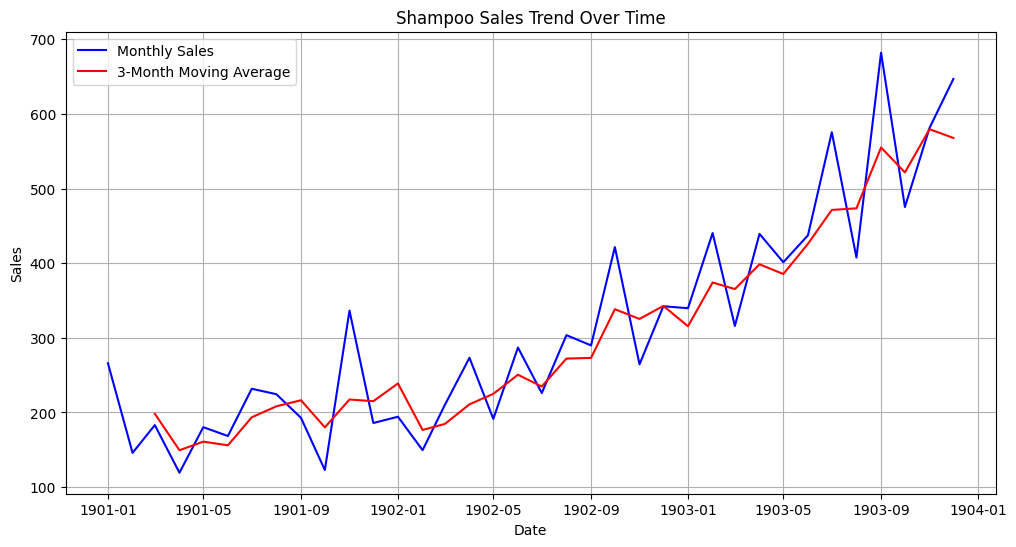

ADF Statistic: 3.0601
p-value: 1.0000
→ Data is NOT stationary → differencing needed

Training Auto ARIMA model...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=430.873, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=405.977, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=408.967, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=429.229, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=403.573, Time=0.15 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=404.633, Time=0.25 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=404.226, Time=0.20 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=402.407, Time=0.22 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=401.463, Time=0.41 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.53 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(2,1,3)

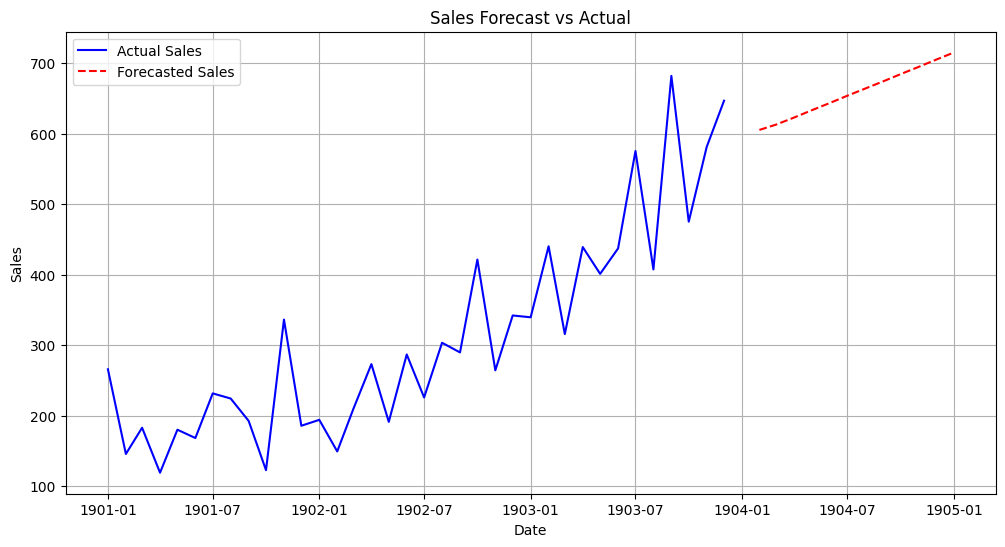


Model Performance:
RMSE: 142.05
MAPE: 19.76%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error

# = LOAD DATA
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv"
df = pd.read_csv(url)
df['Month'] = pd.to_datetime('190' + df['Month'], format='%Y-%m')
df = df.set_index('Month')
df = df.rename(columns={'Sales': 'Sales'})
print("Dataset loaded successfully!")
print(df.head())

# VISUALIZE TRENDS (OVERLAID)
plt.figure(figsize=(12, 6))

# Sales + Moving Average on SAME plot
plt.plot(df['Sales'], label='Monthly Sales', color='blue')
df['MA_3'] = df['Sales'].rolling(window=3).mean()
plt.plot(df['MA_3'], label='3-Month Moving Average', color='red')

plt.title('Shampoo Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

#  CHECK STATIONARITY 
def adf_test(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] > 0.05:
        print("→ Data is NOT stationary → differencing needed")
    else:
        print("→ Data is stationary")

adf_test(df['Sales'])

#  AUTO ARIMA MODEL 
print("\nTraining Auto ARIMA model...")
model = auto_arima(df['Sales'], seasonal=False, trace=True, 
                   error_action='ignore', suppress_warnings=True)

print("\nBest ARIMA model:")
print(model.summary())

# FORECAST FUTURE SALES 
future_periods = 12
forecast = model.predict(n_periods=future_periods)

# FIXED: Use 'ME' instead of deprecated 'M'
forecast_index = pd.date_range(start=df.index[-1], 
                               periods=future_periods + 1, 
                               freq='ME')[1:]

forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'Forecasted_Sales': forecast.round(2)
})

print("\nForecasted Sales Values (next 12 months):")
print(forecast_df)

# Save for submission
forecast_df.to_csv('forecasted_sales.csv', index=False)

#  PLOT FORECAST vs ACTUAL
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], label='Actual Sales', color='blue')
plt.plot(forecast_index, forecast, label='Forecasted Sales', color='red', linestyle='--')
plt.title('Sales Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

# MODEL EVALUATION 
train = df['Sales'][:-6]
test = df['Sales'][-6:]

model_test = auto_arima(train, seasonal=False, suppress_warnings=True)
forecast_test = model_test.predict(n_periods=6)

rmse = np.sqrt(mean_squared_error(test, forecast_test))
mape = np.mean(np.abs((test - forecast_test) / test)) * 100

print(f'\nModel Performance:')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

Project 2:Predicting Heart Disease Using Logistic Regression

Dataset loaded successfully!
Columns: ['Age', 'Gender', 'cp', 'Blood Pressure', 'Cholesterol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'Heart Disease']
   Age  Gender  cp  Blood Pressure  Cholesterol  fbs  restecg  thalach  exang  \
0   63       1   3             145          233    1        0      150      0   
1   37       1   2             130          250    0        1      187      0   
2   41       0   1             130          204    0        0      172      0   
3   56       1   1             120          236    0        1      178      0   
4   57       0   0             120          354    0        1      163      1   

   oldpeak  slope  ca  thal  Heart Disease  
0      2.3      0   0     1              1  
1      3.5      0   0     2              1  
2      1.4      2   0     2              1  
3      0.8      2   0     2              1  
4      0.6      2   0     2              1  

Missing values:
 Age               0
Gender            0
c

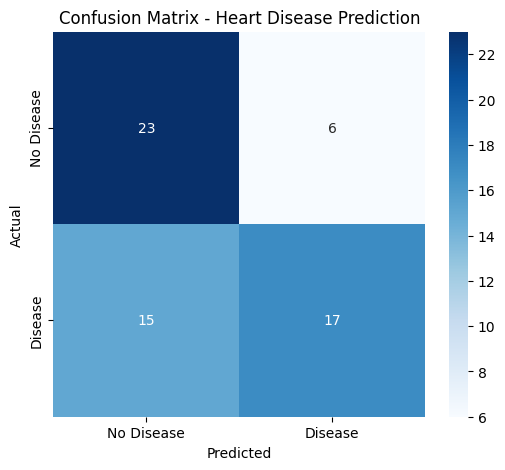


 Evaluation Report Ready:
• Accuracy, Precision, Recall, F1-score printed above
• Confusion Matrix plot generated


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# LOAD DATASET
url = "https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv"
df = pd.read_csv(url)

# Rename columns exactly as per your PDF
df = df.rename(columns={
    'age': 'Age',
    'sex': 'Gender',           
    'chol': 'Cholesterol',
    'trestbps': 'Blood Pressure',  
    'target': 'Heart Disease'     
})

print("Dataset loaded successfully!")
print("Columns:", df.columns.tolist())
print(df.head())

#  CLEANING 
print("\nMissing values:\n", df.isnull().sum())
df.dropna(inplace=True)          # Just in case
df.drop_duplicates(inplace=True)

# FEATURE ENGINEERING 
# Use the exact columns mentioned in PDF
features = ['Age', 'Gender', 'Cholesterol', 'Blood Pressure']
X = df[features]
y = df['Heart Disease']

# Scale numerical features (required for better performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  TRAIN-TEST SPLIT & MODEL
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

print("\nLogistic Regression Model Trained Successfully!")

# EVALUATION (Deliverables) 
y_pred = model.predict(X_test)

print("\n=== Model Performance ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Plot (Deliverable)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Heart Disease Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Optional: Full insights
print("\n Evaluation Report Ready:")
print("• Accuracy, Precision, Recall, F1-score printed above")
print("• Confusion Matrix plot generated")